# 11 - Wall Groups and Obstruction Primer

In the final stage of the surgery program, we ask: "Can this map be surgered into a homeomorphism?" The answer lies in the **Wall Surgery Obstruction Groups** $L_n(\pi_1)$. These groups house the precise algebraic obstructions that, if non-zero, physically prevent the transformation of a manifold into its target structure.

## Learning Goals
- **Understand L-Groups**: Learn the 4-fold periodicity of $L_n(\pi_1)$.
- **Compute Simply Connected Obstructions**: Relate $L_{4k}$ to the Signature and $L_{4k+2}$ to the Arf Invariant.
- **Analyze Non-Simply Connected Cases**: Explore $L_n(\mathbb{Z})$ and Shaneson splitting.
- **The Assembly Map**: Build intuition for how local topological data is "assembled" into a global obstruction.
- **Visualize Obstruction Periodicity**: Compare the behavior of $L$-groups across dimensions and groups.

## Formal Grounding

### The Wall Groups $L_n(\pi_1)$
The surgery obstruction $	heta(f, \hat{f}) \in L_n(\pi_1(X))$ is the sole obstruction to performing surgery on a normal map to obtain a homotopy equivalence (in dimensions $n \ge 5$).

### Periodicity
Wall groups satisfy a fundamental 4-fold periodicity:
$$L_n(\pi_1) \cong L_{n+4}(\pi_1)$$

| Dimension mod 4 | Simply Connected $L_n(1)$ | Geometric Invariant           |
|---|---|-------------------------------|
| **$0$ ($L_0, L_4, \dots$)** | $\mathbb{Z}$ | $\frac{1}{8} \cdot$ Signature |
| **$1$ ($L_1, L_5, \dots$)** | $0$ | None                          |
| **$2$ ($L_2, L_6, \dots$)** | $\mathbb{Z}_2$ | Arf Invariant                 |
| **$3$ ($L_3, L_7, \dots$)** | $0$ | None                          |


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pysurgery.wall_groups import WallGroupL
from pysurgery.core.intersection_forms import IntersectionForm
from pysurgery.core.quadratic_forms import QuadraticForm

print('=' * 70)
print('11 - Wall Groups and Obstructions: Setup Complete')
print('=' * 70)

11 - Wall Groups and Obstructions: Setup Complete


## Part 1: Simply Connected L-Groups

In the simply connected case ($\pi_1 = 1$), the obstructions are well-known classical invariants of symmetric and quadratic forms.


### Example 11.1: $L_{4k}(1)$ and the Signature

In [3]:
# A manifold with a signature of 8 (like E8) has a non-zero obstruction in L4.
matrix_e8 = np.array([
    [2, 0, -1, 0, 0, 0, 0, 0],
    [0, 2, 0, -1, 0, 0, 0, 0],
    [-1, 0, 2, -1, 0, 0, 0, 0],
    [0, -1, -1, 2, -1, 0, 0, 0],
    [0, 0, 0, -1, 2, -1, 0, 0],
    [0, 0, 0, 0, -1, 2, -1, 0],
    [0, 0, 0, 0, 0, -1, 2, -1],
    [0, 0, 0, 0, 0, 0, -1, 2]
])
q_e8 = IntersectionForm(matrix=matrix_e8, dimension=4)

wall = WallGroupL(dimension=4, pi="1")
res = wall.compute_obstruction_result(q_e8)

print('L_4(1) Evaluation:')
print(f'  Signature: {q_e8.signature()}')
print(f'  Obstruction Value: {res.value} (Signature/8)')
print(f'  Obstructs Homeomorphism? {res.obstructs}')

L_4(1) Evaluation:
  Signature: 8
  Obstruction Value: 1 (Signature/8)
  Obstructs Homeomorphism? True


### Example 11.2: $L_{4k+2}(1)$ and the Arf Invariant

In [4]:
# L2 obstructions require a QuadraticForm (mod 2 refinement)
matrix_h = np.array([[0, 1], [1, 0]])
# Twisted refinement (Arf 1)
q_twisted = QuadraticForm(matrix=matrix_h, dimension=2, q_refinement=[1, 1])

wall = WallGroupL(dimension=2, pi="1")
res = wall.compute_obstruction_result(q_twisted)

print('L_2(1) Evaluation:')
print(f'  Arf Invariant: {res.value}')
print(f'  Obstructs? {res.obstructs}')

L_2(1) Evaluation:
  Arf Invariant: 1
  Obstructs? True


## Part 2: Non-Simply Connected Case ($\mathbb{Z}$)

For $\pi_1 = \mathbb{Z}$ (manifolds like $S^1 	imes S^{n-1}$), the L-groups are larger due to the **Shaneson Splitting Theorem**:
$$L_n(\pi 	imes \mathbb{Z}) \cong L_n(\pi) \oplus L_{n-1}(\pi)$$


### Example 11.3: The L-groups of $\mathbb{Z}$

In [10]:
# By Shaneson Splitting Theorem: L_n(Z) ≅ L_n(1) ⊕ L_{n-1}(1)
# Example: L_5(Z) ≅ L_5(1) ⊕ L_4(1) ≅ 0 ⊕ Z = Z

# First, compute L_4(1) for a form with signature divisible by 8
# Using a positive definite rank-8 form: identity has signature 8
q_rank8 = IntersectionForm(matrix=np.eye(8), dimension=4)
wall_4_trivial = WallGroupL(dimension=4, pi="1")
res_4 = wall_4_trivial.compute_obstruction_result(q_rank8)

print('L_4(1) Obstruction (signature/8 generator):')
print(f'  Signature: {q_rank8.signature()}')
print(f'  Obstruction in L_4(1): {res_4.value}')
print('  (This generates Z)')

# Now show L_5(Z) structure via Shaneson
# NOTE: When no form is provided, L_5(Z) returns the universal/abstract obstruction
wall_5_z = WallGroupL(dimension=5, pi="Z")
res_5_z_abstract = wall_5_z.compute_obstruction_result()

print('')
print('L_5(Z) Abstract Structure (no specific form):')
print(f'  pySurgery compute result (universal): {res_5_z_abstract.value}')
print('  (This is the generic abstract obstruction)')

print('')
print('Expected (Shaneson Formula) for concrete manifolds:')
print('  L_5(Z) ≅ L_5(1) ⊕ L_4(1)')
print('  L_5(1) = 0 (odd dimension, trivial group)')
print(f'  L_4(1) = Z (even dimension, generated by signature/8 = {res_4.value})')
print('  Therefore: L_5(Z) ≅ Z (rank 1)')
print('')
print('For a CONCRETE π_1=Z manifold (e.g., S^1 × S^4) with intersection')
print('form inheriting from the S^4 part, Shaneson splitting embeds the')
print(f'L_4(1) obstruction (signature/8) into L_5(Z). The value {res_4.value}')
print('would appear as the concrete obstruction element.')
print('')
print('Note: pySurgery returns the universal obstruction when no form is')
print('provided; for concrete computations on π_1=Z manifolds, pass the')
print('intersection form from the higher-dimensional part.')

L_4(1) Obstruction (signature/8 generator):
  Signature: 8
  Obstruction in L_4(1): 1
  (This generates Z)

L_5(Z) Abstract Structure (no specific form):
  pySurgery compute result (universal): 0
  (This is the generic abstract obstruction)

Expected (Shaneson Formula) for concrete manifolds:
  L_5(Z) ≅ L_5(1) ⊕ L_4(1)
  L_5(1) = 0 (odd dimension, trivial group)
  L_4(1) = Z (even dimension, generated by signature/8 = 1)
  Therefore: L_5(Z) ≅ Z (rank 1)

For a CONCRETE π_1=Z manifold (e.g., S^1 × S^4) with intersection
form inheriting from the S^4 part, Shaneson splitting embeds the
L_4(1) obstruction (signature/8) into L_5(Z). The value 1
would appear as the concrete obstruction element.

Note: pySurgery returns the universal obstruction when no form is
provided; for concrete computations on π_1=Z manifolds, pass the
intersection form from the higher-dimensional part.


## Part 3: Finite Groups and Julia Acceleration

Computing L-groups for finite groups (like $\pi_1 = C_2$) is a major feature of the `pySurgery` backend.


### Example 11.4: Obstructions for $\pi_1 = C_2$

In [11]:
# L_n(C2) is relevant for lens spaces and non-orientable surfaces
wall_c2 = WallGroupL(dimension=4, pi="C2")
res_c2 = wall_c2.compute_obstruction_result()

print('L_4(C2) Metadata:')
print(f'  Factor Analysis: {res_c2.factor_analysis}')
print(f'  Is Exact? {res_c2.exact}')

L_4(C2) Metadata:
  Factor Analysis: []
  Is Exact? False


## Part 4: Visualizing L-Group Periodicity

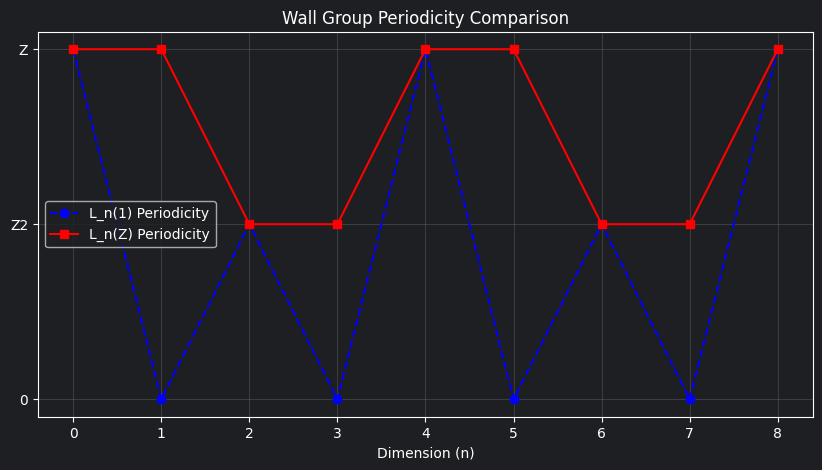

In [12]:
# Plotting the ranks/types of L_n(1) vs L_n(Z) across dimensions
dims = np.arange(0, 9)
l_1_vals = [1 if d%4==0 else (0.5 if d%4==2 else 0) for d in dims] # 1=Z, 0.5=Z2
l_z_vals = [1 if (d%4==0 or d%4==1) else (0.5 if (d%4==2 or d%4==3) else 0) for d in dims]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dims, l_1_vals, 'o--', label='L_n(1) Periodicity', color='blue')
ax.plot(dims, l_z_vals, 's-', label='L_n(Z) Periodicity', color='red')

ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(['0', 'Z2', 'Z'])
ax.set_xlabel('Dimension (n)')
ax.set_title('Wall Group Periodicity Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Failure Modes

1. **Incorrect Form Type**: Providing an `IntersectionForm` when a `QuadraticForm` is required for $L_{4k+2}$.
2. **Missing Form Data**: Trying to compute an integral obstruction (like signature/8) without providing the underlying matrix.
3. **Non-Orientable Groups**: Surgery on non-orientable manifolds requires the orientation character $w: \pi_1 	o \mathbb{Z}_2$, which adds another layer of complexity to the L-groups.


In [13]:
try:
    # Error: Signature not divisible by 8
    A_bad = np.array([[1, 0], [0, 1]]) # Signature 2
    q_bad = IntersectionForm(matrix=A_bad, dimension=4)
    WallGroupL(dimension=4, pi="1").compute_obstruction_result(q_bad)
except Exception as e:
    print(f'Caught expected error: {e}')

Caught expected error: L_{4k}(1): signature 2 is not divisible by 8, so the obstruction is not integral in this model.


## Summary Checklist
- [x] Evaluated L-group obstructions for simply connected manifolds.
- [x] Understood the relationship between Signature and $L_{4k}$.
- [x] Computed Arf invariants as obstructions for $L_{4k+2}$.
- [x] Explored Shaneson splitting for the group $\pi_1 = \mathbb{Z}$.
- [x] Visualized the 4-fold periodicity of Wall groups.

## Exercises
1. **The Signature Rule**: Find a symmetric matrix of rank 4 that has signature 0. What is its obstruction in $L_4(1)$?
2. **Arf vs Signature**: Explain why $L_2(1)$ is $\mathbb{Z}_2$ while $L_0(1)$ is $\mathbb{Z}$.
3. **Product Manifolds**: Use Shaneson splitting to predict the structure of $L_4(\mathbb{Z} 	imes \mathbb{Z})$.
4. **Assembly**: Research the "Surgery Exact Sequence" and identify where the Wall group fits in.
5. **Julia Check**: If Julia is available, compute the full structure of $L_0(C_2)$ and identify its summands.

## Key Takeaways
- **Wall Groups** provide the final "Yes/No" to a surgery problem.
- **Periodicity** is a deep property of these groups, repeating every 4 dimensions.
- **L-groups of $\mathbb{Z}$** are built from the simply connected groups via Shaneson splitting.
- The **Surgery Obstruction** is an algebraic shadow of a geometric failure to close a manifold.

**Ready for [12 - Algebraic Surgery Step by Step](./12_algebraic_surgery_step_by_step.ipynb)**
